# Desktop parameter search — round 3 (exhaust cps/cpr + threshold map)

Same re-anchored data (forecast_start 2026-07-06, center 48,520,449 final, target 48,584,362, gap
+63,913). Round 2 showed the top-3 levers topping out ~28k short. Round 3 pushes the two monotonic
levers into their low ranges (`cps` 0.02–0.08, `cpr` 0.35–0.55), finely maps the jumpy
`holiday_threshold` (−0.007 … −0.042), and adds aggressive `cps`+`cpr`(+threshold) combos — to find
the realistic **param-only ceiling** before deciding how much Win10 headwind to add back.

Reads **round2 ∪ round3** so each single-knob scan curve is complete. Overlays `l`+`o` applied;
Win10 headwind (−1,370,000) added at the display layer here, not in the scan.

Outputs: `results.csv` + `plots/desktop_gradient_round3/{threshold,cps,cpr}_scan.png` + `combos.png`.


In [1]:
# [gr3-setup]
import os
import glob
import json
import sys
import time
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from google.cloud import bigquery

os.chdir(subprocess.run(["git", "rev-parse", "--show-toplevel"],
                        capture_output=True, text=True).stdout.strip())

# Round 3 reads round2 ∪ round3 so single-knob scan curves are complete (same re-anchored data).
ROUND_DIRS = [
    "research/param-scans/results/desktop_gradient_round2",
    "research/param-scans/results/desktop_gradient_round3",
]
OUT_DIR = "research/param-scans/results/desktop_gradient_round3"
PLOTS_DIR = "research/param-scans/plots/desktop_gradient_round3"
ADJUSTMENTS_DIR = "data-official/2026-07/adjustments"
os.makedirs(PLOTS_DIR, exist_ok=True)

FORECAST_START = pd.Timestamp("2026-07-06")
FORECAST_START_STR = "2026-07-06"
DISPLAY_START = pd.Timestamp("2026-01-01")
DISPLAY_END = pd.Timestamp("2026-12-31")
MEASUREMENT_DATE = pd.Timestamp("2026-12-15")
BQ_START = "2025-12-04"

HEADWIND_DEC15 = -1_370_000
HEADWIND_ADDBACK_MAX = 10_000       # currently-authorized headwind softening
CENTER_KPI_PRE = 49_890_449
CURRENT_FINAL = 48_520_449
TARGET_FINAL = 48_584_362

DEFAULTS = {
    "prophet_changepoint_prior_scale": 0.15983, "prophet_recent_weeks": 13,
    "prophet_changepoint_range": 0.7, "prophet_n_changepoints": 25,
    "holiday_threshold": -0.032, "holiday_max_radius": 5,
    "holiday_min_radius": 3, "holiday_effect_floor": -0.6,
}
SHORT = {"prophet_changepoint_prior_scale": "cps", "prophet_changepoint_range": "cpr",
         "holiday_threshold": "threshold"}

print(f"Re-anchored center final = {CURRENT_FINAL:,}   target = {TARGET_FINAL:,}   "
      f"gap = {TARGET_FINAL - CURRENT_FINAL:+,}")


Re-anchored center final = 48,520,449   target = 48,584,362   gap = +63,913


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# [gr3-helpers]
sys.path.insert(0, "data-official/2026-06")
from export_canonical_curves import display_ma  # noqa: E402

SEG_ALL = '{"os": "ALL"}'


def daily_to_28ma(dates, values):
    s = pd.Series(np.asarray(values, dtype=float), index=pd.to_datetime(np.asarray(dates)))
    return s.sort_index().rolling(28).mean()


def render_adjustment(spec, date_index):
    idx = pd.DatetimeIndex(date_index)
    desktop = pd.Series(0.0, index=idx)
    if spec["type"] == "linear_ramp":
        start = pd.Timestamp(spec["start_date"])
        anchor = pd.Timestamp(spec["anchor_date"])
        total_days = (anchor - start).days
        elapsed = np.maximum(0, (idx - start).days)
        desktop[:] = spec.get("desktop_dau", 0) * elapsed / total_days
    elif spec["type"] == "step":
        start = pd.Timestamp(spec["start_date"])
        end = pd.Timestamp(spec["end_date"]) if "end_date" in spec else idx[-1]
        desktop[(idx >= start) & (idx <= end)] = spec.get("desktop_dau", 0)
    return desktop


def load_desktop_adjustment(date_index):
    idx = pd.DatetimeIndex(date_index)
    total = pd.Series(0.0, index=idx)
    for path in sorted(glob.glob(f"{ADJUSTMENTS_DIR}/*.json")):
        with open(path) as f:
            total += render_adjustment(json.load(f), idx)
    return total


def all_labels():
    seen = set()
    for d in ROUND_DIRS:
        for x in os.listdir(d):
            if os.path.isdir(f"{d}/{x}"):
                seen.add(x)
    return sorted(seen)


def find_probe_parquet(label):
    for d in ROUND_DIRS:
        hits = glob.glob(f"{d}/{label}/*/mozaic_daily_forecast.{FORECAST_START_STR}.ld-D.adj-lo.parquet")
        if hits:
            return hits[0]
    return None


def probe_config(label):
    for d in ROUND_DIRS:
        pj = glob.glob(f"{d}/{label}/*/parameters.json")
        if pj:
            return json.load(open(pj[0]))["config"]
    return None


def nondefault(cfg):
    return {k: v for k, v in cfg.items() if abs(v - DEFAULTS[k]) > 1e-9}


def all_desktop_daily(parquet_path):
    df = pd.read_parquet(parquet_path)
    df["target_date"] = pd.to_datetime(df["target_date"])
    m = df[(df.data_source == "legacy_desktop") & (df.country == "ALL")
           & (df.app_name == "desktop") & (df.segment == SEG_ALL)]
    return m.sort_values("target_date")[["target_date", "dau"]].reset_index(drop=True)


def dec15_pre_headwind(parquet_path):
    d = all_desktop_daily(parquet_path)
    s = d.set_index("target_date")["dau"].astype(float)
    return float(s.rolling(28, min_periods=28).mean().loc[MEASUREMENT_DATE])


def forecast_ma_final(parquet_path):
    d = all_desktop_daily(parquet_path)
    ma = display_ma(d["target_date"], d["dau"], FORECAST_START)
    adj = load_desktop_adjustment(ma.index)
    out = ma.copy()
    fmask = out.index >= FORECAST_START
    out[fmask] = out[fmask] + adj[fmask]
    return out


In [3]:
# [gr2-actuals]
client = bigquery.Client(project="moz-fx-data-bq-data-science")
sql = f"""
    SELECT submission_date AS date, SUM(dau) AS dau
    FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
    WHERE app_name = "Firefox Desktop"
      AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE("America/Los_Angeles") - 2
    GROUP BY submission_date ORDER BY 1
"""
t0 = time.time()
sys.stdout.write("querying desktop actuals...")
sys.stdout.flush()
desktop_actuals = client.query(sql).to_dataframe()
desktop_actuals["date"] = pd.to_datetime(desktop_actuals["date"])
desktop_actual_ma = daily_to_28ma(desktop_actuals["date"], desktop_actuals["dau"])
sys.stdout.write(f" {len(desktop_actuals)} rows ({time.time() - t0:.1f}s); "
                 f"latest {desktop_actuals['date'].max().date()}\n")


querying desktop actuals...

 214 rows (8.4s); latest 2026-07-05


36

In [4]:
# [gr3-results-table]
labels = all_labels()
center_pre = dec15_pre_headwind(find_probe_parquet("center"))
assert abs(center_pre - CENTER_KPI_PRE) < 1, f"center drift: {center_pre:,.0f} vs {CENTER_KPI_PRE:,}"

rows = []
for lab in labels:
    pq = find_probe_parquet(lab)
    if pq is None:
        continue
    nd = nondefault(probe_config(lab))
    pre = dec15_pre_headwind(pq)
    rows.append({
        "label": lab,
        "changes": ", ".join(f"{SHORT.get(k, k)}={v:g}" for k, v in nd.items()) or "center",
        "n_knobs": len(nd),
        "pre": pre,
        "final": pre + HEADWIND_DEC15,
        "vs_center": pre - center_pre,
        "vs_target": (pre + HEADWIND_DEC15) - TARGET_FINAL,
    })
res = pd.DataFrame(rows).sort_values("final", ascending=False).reset_index(drop=True)
res.to_csv(f"{OUT_DIR}/results.csv", index=False)

best = res.iloc[0]
print(f"center final = {CURRENT_FINAL:,}   target = {TARGET_FINAL:,}   gap = {TARGET_FINAL - CURRENT_FINAL:+,}")
print(f"BEST config  = {best['label']}  ({best['changes']})")
print(f"  final = {best['final']:,.0f}   vs target = {best['vs_target']:+,.0f}")
print(f"  + up to {HEADWIND_ADDBACK_MAX:,} headwind softening => {best['final'] + HEADWIND_ADDBACK_MAX:,.0f} "
      f"(residual {best['final'] + HEADWIND_ADDBACK_MAX - TARGET_FINAL:+,.0f})\n")

show = res.copy()
show["final"] = show["final"].map(lambda v: f"{v:,.0f}")
for c in ["vs_center", "vs_target"]:
    show[c] = show[c].map(lambda v: f"{v:+,.0f}")
print(show[["label", "changes", "final", "vs_center", "vs_target"]].to_string(index=False))
res


center final = 48,520,449   target = 48,584,362   gap = +63,913
BEST config  = thresh__m007  (threshold=-0.007)
  final = 48,602,542   vs target = +18,180
  + up to 10,000 headwind softening => 48,612,542 (residual +28,180)

                       label                                 changes      final vs_center vs_target
                thresh__m007                        threshold=-0.007 48,602,542   +82,093   +18,180
                thresh__m012                        threshold=-0.012 48,570,814   +50,365   -13,548
combo__thr017_cps08983_cpr55 cpr=0.55, threshold=-0.017, cps=0.08983 48,556,077   +35,627   -28,285
                thresh__m019                        threshold=-0.019 48,539,962   +19,513   -44,400
                   cpr__0.55                                cpr=0.55 48,533,021   +12,572   -51,341
                cps__0.08983                             cps=0.08983 48,532,551   +12,102   -51,811
                thresh__m017                        threshold=-0.017 48,530

,label,changes,n_knobs,pre,final,vs_center,vs_target
0,thresh__m007,threshold=-0.007,1,4.997254e+07,4.860254e+07,82093.435637,18180.439745
1,thresh__m012,threshold=-0.012,1,4.994081e+07,4.857081e+07,50364.505114,-13548.490778
2,combo__thr017_cps08983_cpr55,"cpr=0.55, threshold=-0.017, cps=0.08983",3,4.992608e+07,4.855608e+07,35627.498729,-28285.497164
3,thresh__m019,threshold=-0.019,1,4.990996e+07,4.853996e+07,19513.398741,-44399.597151
4,cpr__0.55,cpr=0.55,1,4.990302e+07,4.853302e+07,12571.627209,-51341.368683
5,cps__0.08983,cps=0.08983,1,4.990255e+07,4.853255e+07,12102.124616,-51810.871276
6,thresh__m017,threshold=-0.017,1,4.990046e+07,4.853046e+07,10007.284901,-53905.710991
7,cps__0.10983,cps=0.10983,1,4.989632e+07,4.852632e+07,5866.450084,-58046.545808
8,combo__cps10983_cpr60,"cpr=0.6, cps=0.10983",2,4.989419e+07,4.852419e+07,3741.906654,-60171.089238
9,cpr__0.60,cpr=0.6,1,4.989251e+07,4.852251e+07,2058.419644,-61854.576248


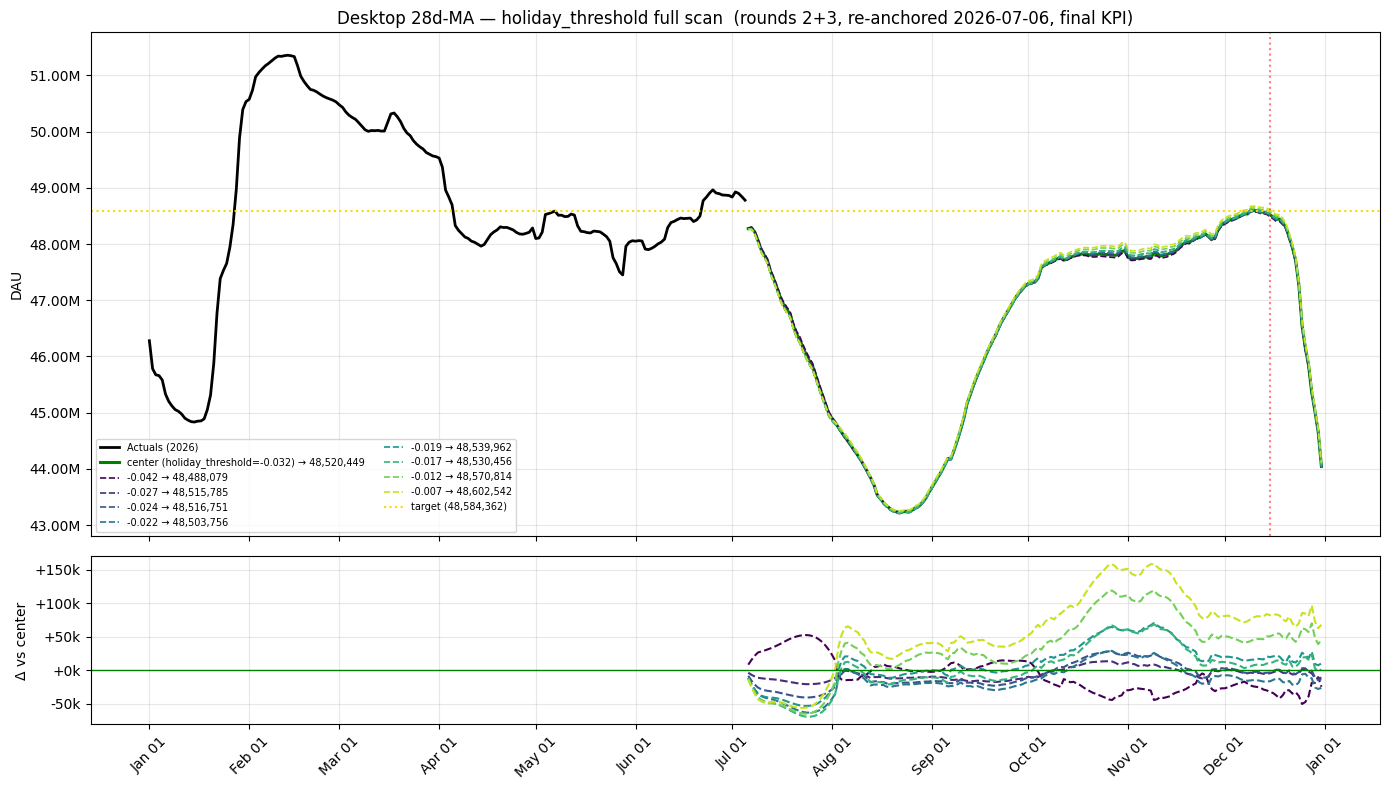

saved research/param-scans/plots/desktop_gradient_round3/threshold_scan.png


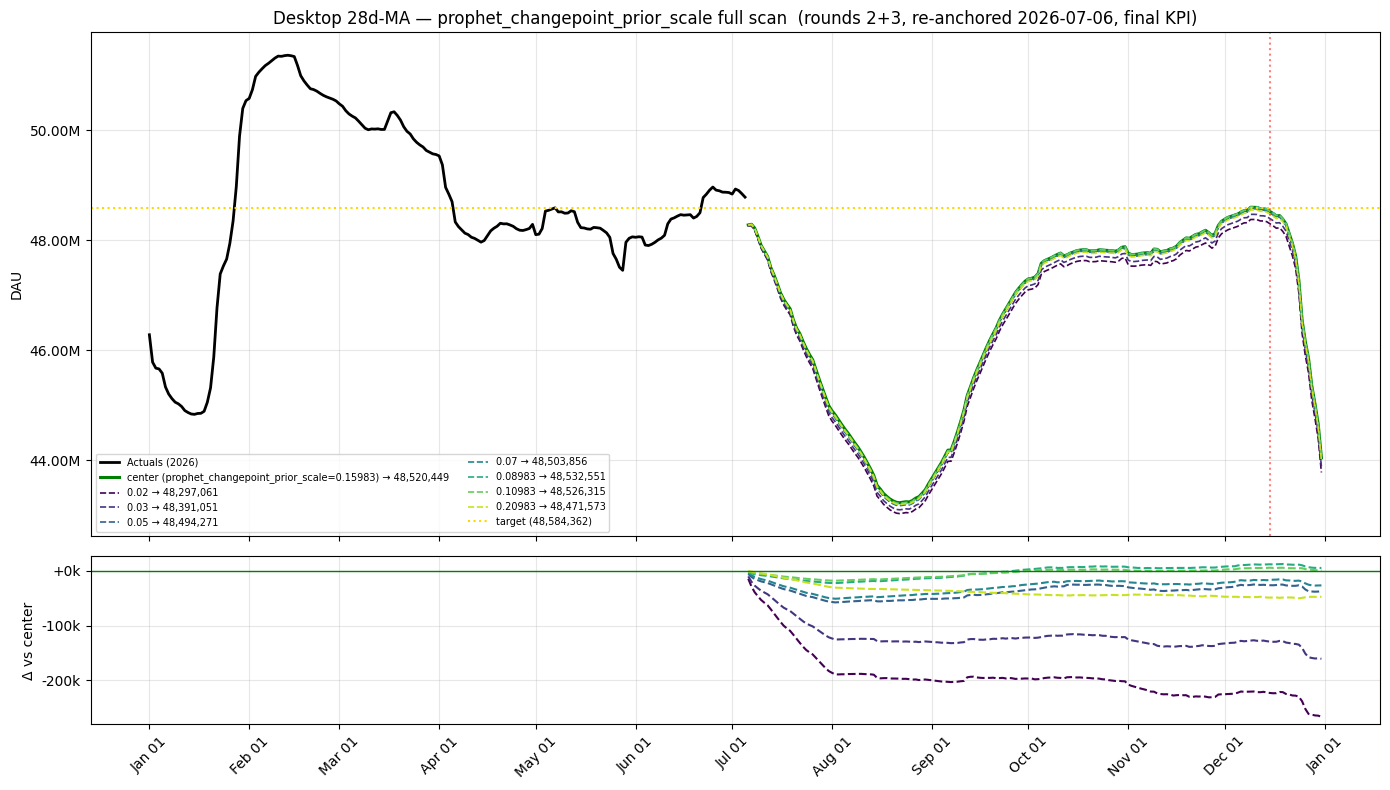

saved research/param-scans/plots/desktop_gradient_round3/cps_scan.png


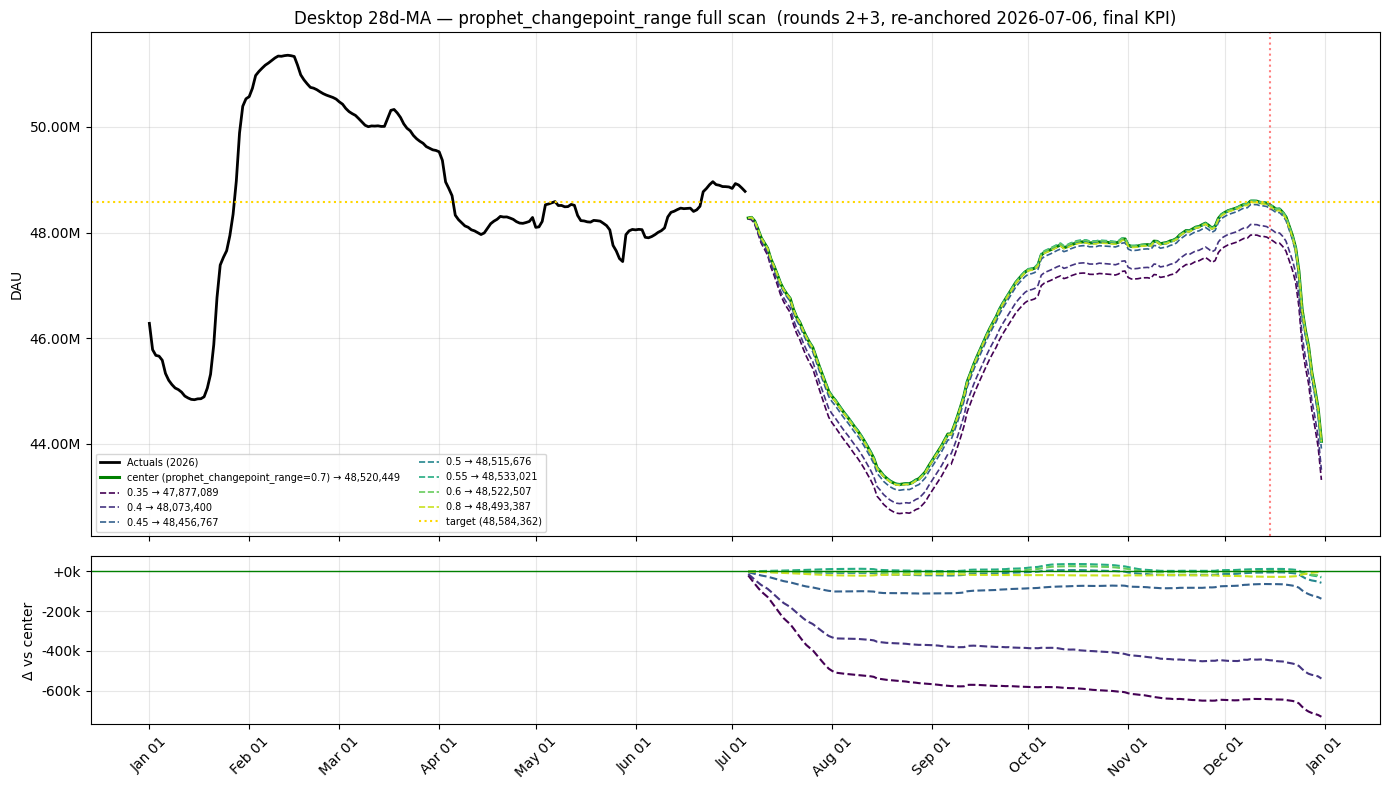

saved research/param-scans/plots/desktop_gradient_round3/cpr_scan.png


In [5]:
# [gr3-single-knob-scans]
def clip_display(s):
    return s[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)].dropna()


def clip_fc(s):
    return s[(s.index >= FORECAST_START) & (s.index <= DISPLAY_END)].dropna()


def mfmt(x, pos):
    return f"{x / 1e6:.2f}M"


labels = all_labels()
center_ma = forecast_ma_final(find_probe_parquet("center"))

for field, short in [("holiday_threshold", "threshold"),
                     ("prophet_changepoint_prior_scale", "cps"),
                     ("prophet_changepoint_range", "cpr")]:
    variants = []
    for lab in labels:
        if lab == "center":
            continue
        nd = nondefault(probe_config(lab))
        if len(nd) == 1 and field in nd:
            variants.append((nd[field], lab))
    variants.sort()
    if not variants:
        continue

    fig, (ax, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                  gridspec_kw={"height_ratios": [3, 1]})
    ax.plot(clip_display(desktop_actual_ma), color="black", lw=2, label="Actuals (2026)")
    ax.plot(clip_fc(center_ma), color="green", lw=2.2,
            label=f"center ({field}={DEFAULTS[field]:g}) → {center_ma.loc[MEASUREMENT_DATE]:,.0f}")
    colors = cm.viridis(np.linspace(0, 0.92, len(variants)))
    for (val, lab), col in zip(variants, colors):
        ma = forecast_ma_final(find_probe_parquet(lab))
        ax.plot(clip_fc(ma), color=col, lw=1.2, ls="--",
                label=f"{val:g} → {ma.loc[MEASUREMENT_DATE]:,.0f}")
        d = clip_fc(ma - center_ma)
        ax2.plot(d.index, d.values, color=col, ls="--")
    ax.axhline(TARGET_FINAL, color="gold", ls=":", lw=1.5, label=f"target ({TARGET_FINAL:,})")
    ax.axvline(MEASUREMENT_DATE, color="red", ls=":", alpha=0.5)
    ax.set_title(f"Desktop 28d-MA — {field} full scan  (rounds 2+3, re-anchored 2026-07-06, final KPI)",
                 fontsize=12)
    ax.set_ylabel("DAU")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(mfmt))
    ax.legend(loc="lower left", fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)
    ax2.axhline(0, color="green", lw=1)
    ax2.set_ylabel("Δ vs center")
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:+.0f}k"))
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax2.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
    plt.tight_layout()
    out = f"{PLOTS_DIR}/{short}_scan.png"
    plt.savefig(out, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"saved {out}")


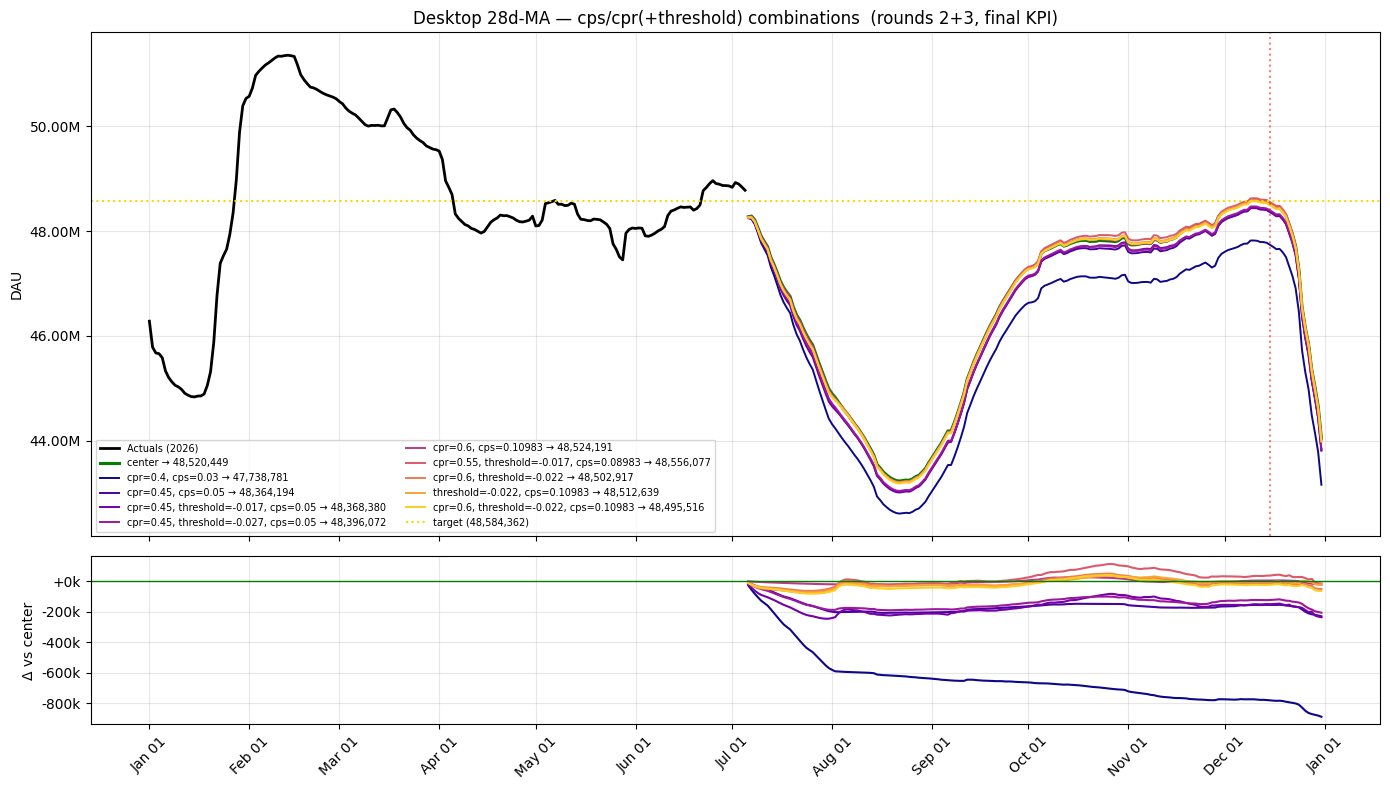

saved research/param-scans/plots/desktop_gradient_round3/combos.png

best combo: (np.float64(48556076.502836406), 'combo__thr017_cps08983_cpr55')


In [6]:
# [gr3-combo-plot]
# All combos across rounds 2+3, plus the best single-knob configs for reference.
combo_labels = [l for l in all_labels() if l.startswith("combo__")]

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1]})
ax.plot(clip_display(desktop_actual_ma), color="black", lw=2, label="Actuals (2026)")
ax.plot(clip_fc(center_ma), color="green", lw=2.2,
        label=f"center → {center_ma.loc[MEASUREMENT_DATE]:,.0f}")
colors = cm.plasma(np.linspace(0, 0.9, max(1, len(combo_labels))))
combo_finals = []
for lab, col in zip(combo_labels, colors):
    ma = forecast_ma_final(find_probe_parquet(lab))
    f = ma.loc[MEASUREMENT_DATE]
    combo_finals.append((f, lab))
    nd = nondefault(probe_config(lab))
    desc = ", ".join(f"{SHORT.get(k, k)}={v:g}" for k, v in nd.items())
    ax.plot(clip_fc(ma), color=col, lw=1.4, label=f"{desc} → {f:,.0f}")
    d = clip_fc(ma - center_ma)
    ax2.plot(d.index, d.values, color=col)
ax.axhline(TARGET_FINAL, color="gold", ls=":", lw=1.5, label=f"target ({TARGET_FINAL:,})")
ax.axvline(MEASUREMENT_DATE, color="red", ls=":", alpha=0.5)
ax.set_title("Desktop 28d-MA — cps/cpr(+threshold) combinations  (rounds 2+3, final KPI)", fontsize=12)
ax.set_ylabel("DAU")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(mfmt))
ax.legend(loc="lower left", fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
ax2.axhline(0, color="green", lw=1)
ax2.set_ylabel("Δ vs center")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:+.0f}k"))
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
out = f"{PLOTS_DIR}/combos.png"
plt.savefig(out, dpi=130, bbox_inches="tight")
plt.show()
print(f"saved {out}")
print("\nbest combo:", max(combo_finals))
